### Identify Handwritten Digits Using Logistic Regression in PyTorch

It is a very command technique that is used for classification. also PyTorch is a deep learning framework which has been developed by facebook.

##### 1. Importing Libraries

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 2. Importing Dataset

In [21]:
import torchvision.datasets as dataset
import torchvision.transforms as transforms

training_data = dataset.MNIST(
    root = './data',
    train = True,
    transform = transforms.ToTensor(),
    download = True
)


test_data = dataset.MNIST(
    root = './data',
    train = False,
    transform = transforms.ToTensor()
)

In [22]:
import torch

train_loader = torch.utils.data.DataLoader(
    dataset = training_data,
    batch_size = 64,
    shuffle = True
)

test_loader = torch.utils.data.DataLoader(
    dataset = test_data,
    batch_size = 64,
    shuffle = False
)

##### 3. Build the Model

In [23]:
import torch.nn as nn
# Hyper Parameters
input_size = 784
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

# Build the Model
class LogisticRegression(nn.Module):

    def __init__(self, input_size, num_classes):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        output = self.linear(x)
        return output

In [24]:
model = LogisticRegression(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

##### 4. Train the Model

In [25]:
from torch.autograd import Variable

# Store losses per epoch for plotting
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0
    train_batches = 0
    
    for i, (images, labels) in enumerate(train_loader):
        images = Variable(images.view(-1, 28*28))
        labels = Variable(labels)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        train_batches += 1

        if (i + 1) % 100 ==0:
            print("Epoch [% d/% d], Step: [% d/% d], Loss: %.4f" % (epoch + 1, num_epochs, i + 1, len(training_data) // batch_size, loss.item()))
    
    # Calculate average training loss for this epoch
    avg_train_loss = epoch_train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # Evaluation phase
    model.eval()
    epoch_test_loss = 0
    test_batches = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = Variable(images.view(-1, 28 * 28))
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            epoch_test_loss += loss.item()
            test_batches += 1
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum()
    
    # Calculate average test loss for this epoch
    avg_test_loss = epoch_test_loss / test_batches
    test_losses.append(avg_test_loss)
    
    accuracy = 100 * correct / total
    print("Epoch [% d/% d] - Train Loss: %.4f, Test Loss: %.4f, Test Accuracy: %.2f%%" % 
          (epoch + 1, num_epochs, avg_train_loss, avg_test_loss, accuracy))

Epoch [ 1/ 5], Step: [ 100/ 600], Loss: 2.1598
Epoch [ 1/ 5], Step: [ 200/ 600], Loss: 2.1594
Epoch [ 1/ 5], Step: [ 300/ 600], Loss: 2.0048
Epoch [ 1/ 5], Step: [ 400/ 600], Loss: 1.9137
Epoch [ 1/ 5], Step: [ 500/ 600], Loss: 1.9106
Epoch [ 1/ 5], Step: [ 600/ 600], Loss: 1.8213
Epoch [ 1/ 5], Step: [ 700/ 600], Loss: 1.6689
Epoch [ 1/ 5], Step: [ 800/ 600], Loss: 1.6179
Epoch [ 1/ 5], Step: [ 900/ 600], Loss: 1.5434
Epoch [ 1/ 5] - Train Loss: 1.9167, Test Loss: 1.5772, Test Accuracy: 77.36%
Epoch [ 2/ 5], Step: [ 100/ 600], Loss: 1.5809
Epoch [ 2/ 5], Step: [ 200/ 600], Loss: 1.4863
Epoch [ 2/ 5], Step: [ 300/ 600], Loss: 1.5146
Epoch [ 2/ 5], Step: [ 400/ 600], Loss: 1.4708
Epoch [ 2/ 5], Step: [ 500/ 600], Loss: 1.2949
Epoch [ 2/ 5], Step: [ 600/ 600], Loss: 1.3986
Epoch [ 2/ 5], Step: [ 700/ 600], Loss: 1.2554
Epoch [ 2/ 5], Step: [ 800/ 600], Loss: 1.1952
Epoch [ 2/ 5], Step: [ 900/ 600], Loss: 1.2156
Epoch [ 2/ 5] - Train Loss: 1.3926, Test Loss: 1.2070, Test Accuracy: 81.58%


##### 5. Model Evaluation 

In [26]:
# Final Model Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = Variable(images.view(-1, 28 * 28))
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum()

print('Final Accuracy of the model on the 10000 test images: % d %%' % (100 * correct / total))

Final Accuracy of the model on the 10000 test images:  84 %


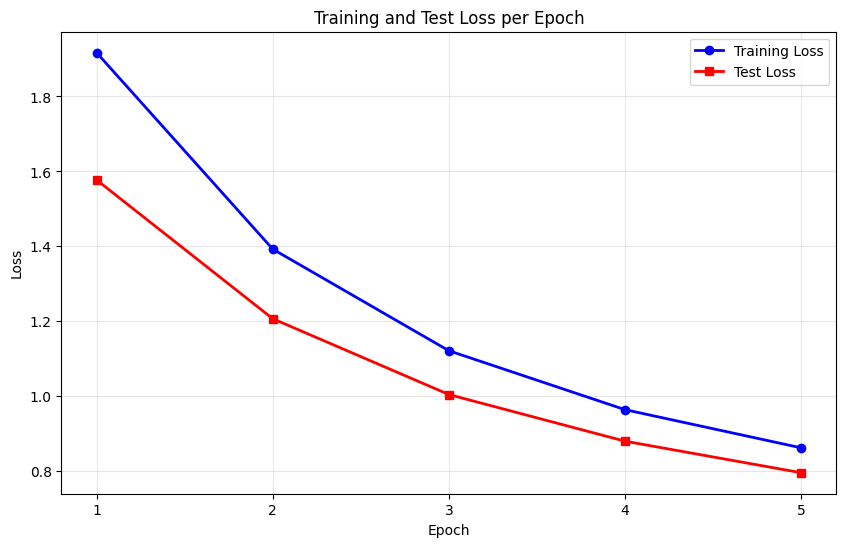

In [27]:
plt.figure(figsize=(10, 6))
epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, test_losses, label='Test Loss', color='red', linewidth=2, marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(epochs_range)
plt.show()